In [1]:
##### SpaceX Falcon 9 First Stage Landing Prediction
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

In [2]:
import pandas as pd
import requests
from io import StringIO

# Use requests library instead of js fetch for standard Python environments
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = requests.get(URL)  # Use requests.get() instead of fetch
dataset_part_2_csv = StringIO(resp.text)  # Use StringIO with resp.text for CSV data
df = pd.read_csv(dataset_part_2_csv)  # Added missing pandas import
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


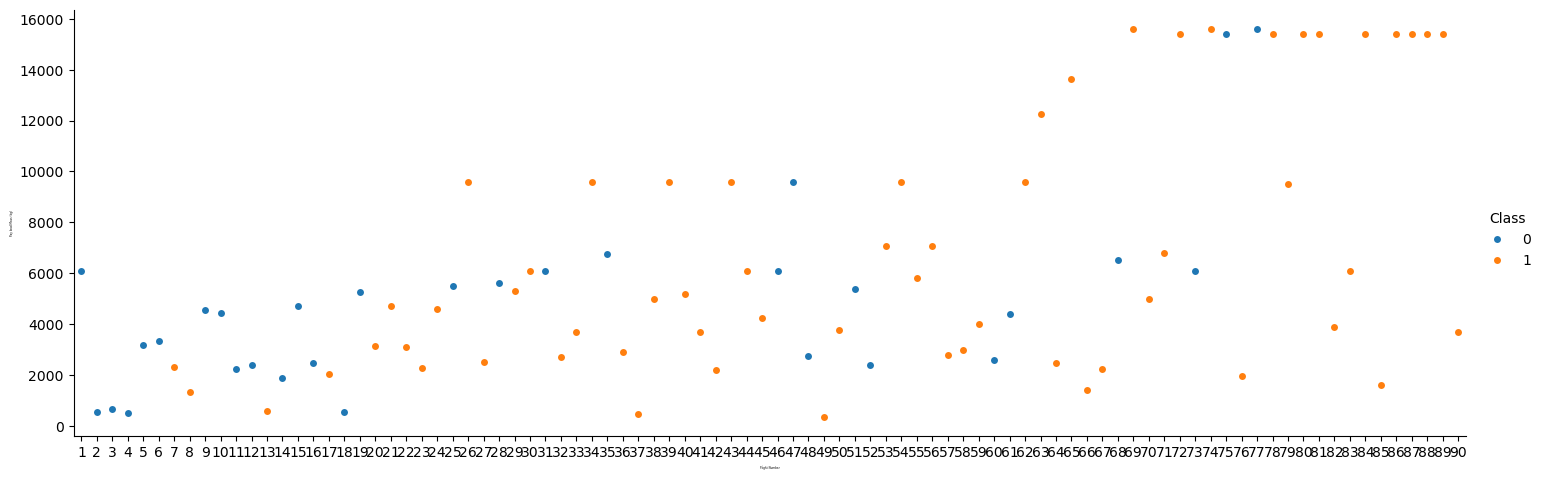

In [3]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 3)
plt.xlabel("Flight Number",fontsize=2)
plt.ylabel("Pay load Mass (kg)",fontsize=2)
plt.show()

In [4]:
print(df.columns)

Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude',
       'Class'],
      dtype='str')


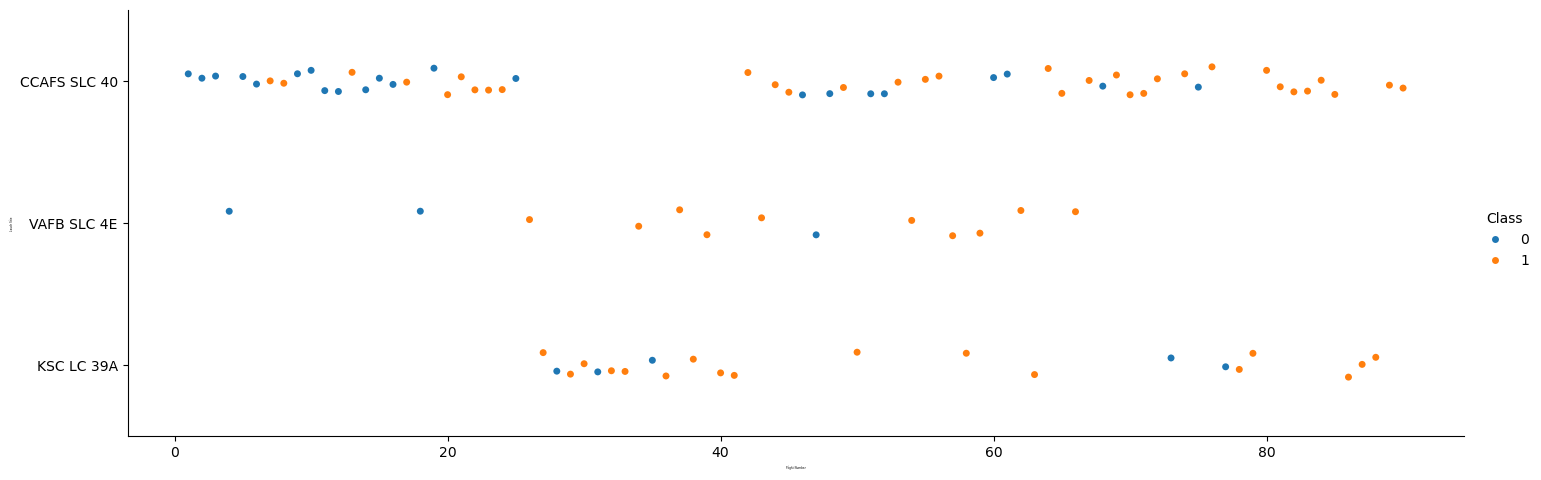

In [5]:
sns.catplot(y='LaunchSite', x='FlightNumber', hue="Class", data=df, aspect = 3)
plt.xlabel("Flight Number", fontsize =2)
plt.ylabel("Lauch Site", fontsize =2)
plt.show()

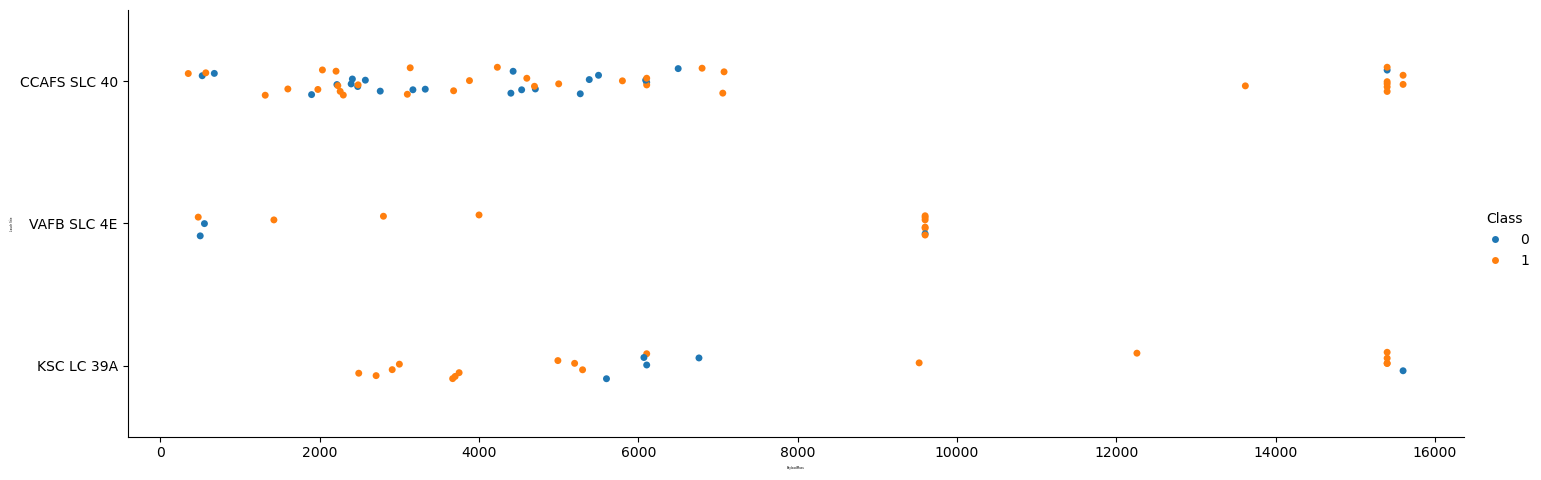

In [6]:
sns.catplot(y='LaunchSite', x='PayloadMass', hue="Class", data=df, aspect = 3)
plt.xlabel("PayloadMass", fontsize =2)
plt.ylabel("Lauch Site", fontsize =2)
plt.show()

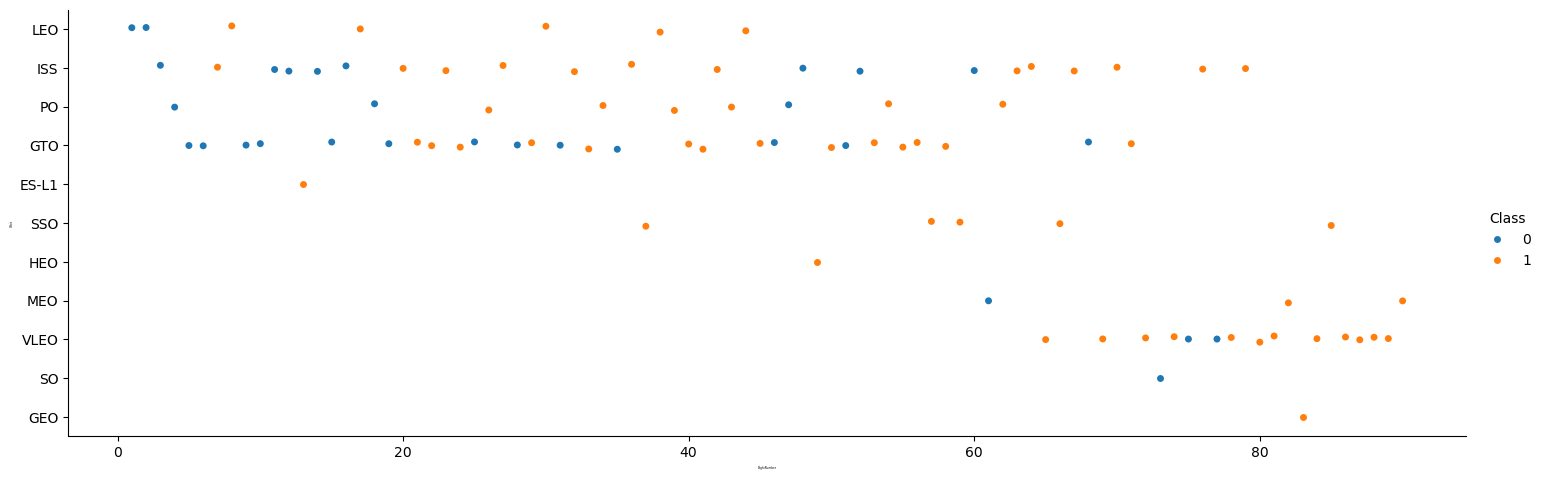

In [7]:
sns.catplot(y='Orbit', x='FlightNumber', hue="Class", data=df, aspect = 3)
plt.xlabel("FlightNumber", fontsize =2)
plt.ylabel("Orbit", fontsize =2)
plt.show()

In [8]:
import matplotlib.pyplot as plt

success_rate = df.groupby('Orbit')['Class'].mean()
print(success_rate )


Orbit
ES-L1    1.000000
GEO      1.000000
GTO      0.518519
HEO      1.000000
ISS      0.619048
LEO      0.714286
MEO      0.666667
PO       0.666667
SO       0.000000
SSO      1.000000
VLEO     0.857143
Name: Class, dtype: float64


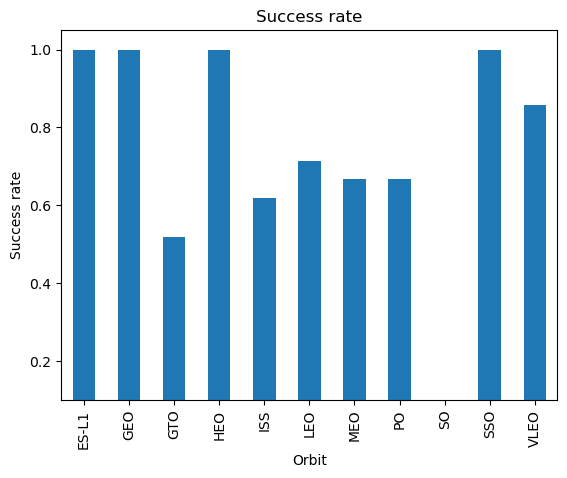

In [9]:
success_rate.plot(kind = 'bar')
plt.title('Success rate')
plt.xlabel('Orbit')
plt.ylabel('Success rate')
plt.ylim(0.1)
plt.show()

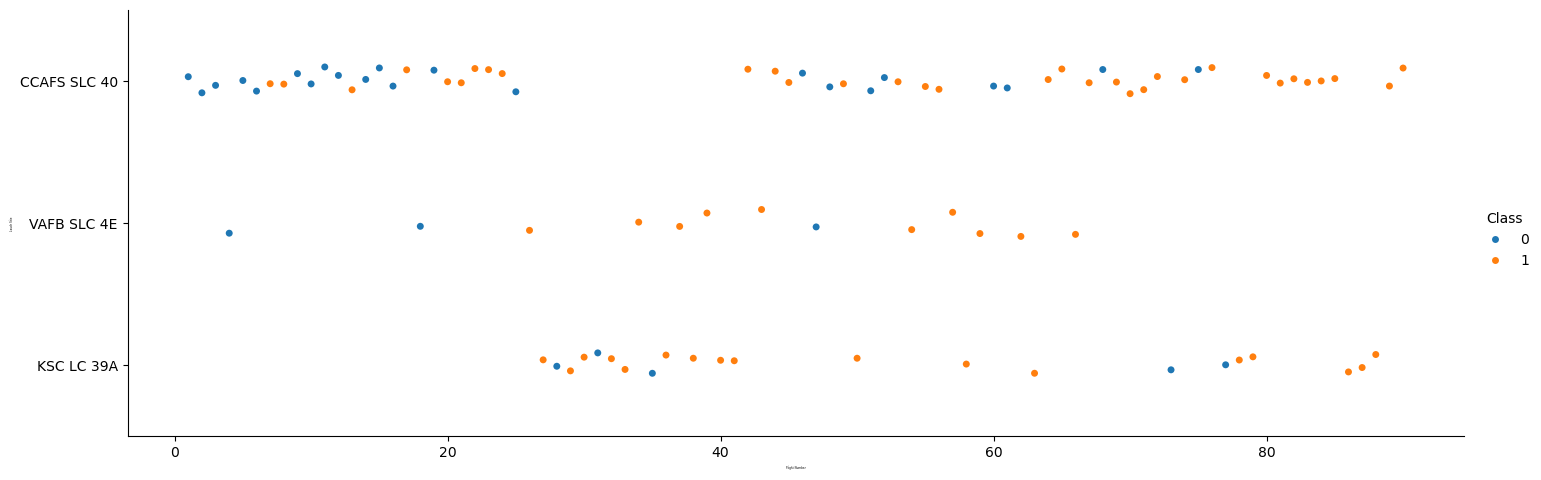

In [10]:
sns.catplot(y='LaunchSite', x='FlightNumber', hue="Class", data=df, aspect = 3)
plt.xlabel("Flight Number", fontsize =2)
plt.ylabel("Lauch Site", fontsize =2)
plt.show()

In [11]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [12]:
success_per_year = df.groupby(['Date'])['Class'].sum()

In [13]:
print(success_per_year)

Date
2010     0
2012     0
2013     0
2014     2
2015     2
2016     5
2017    15
2018    11
2019     9
2020    16
Name: Class, dtype: int64


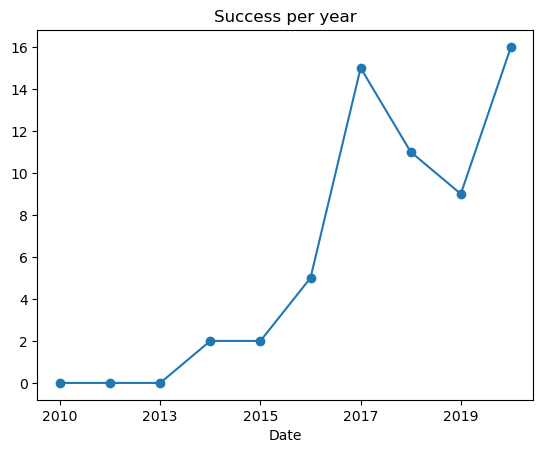

In [14]:
success_per_year.plot(
    x="Date",
    y="Successes",
    kind="line",
    marker="o",
    title="Success per year"
)
plt.show()

In [15]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


In [16]:
df_encoded = pd.get_dummies(df, columns = df.select_dtypes(include=['object', 'category']).columns,dtype=int)

/var/folders/np/v9js13r17k9_qp03z_bwglkh0000gn/T/ipykernel_28521/2520470111.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_encoded = pd.get_dummies(df, columns = df.select_dtypes(include=['object', 'category']).columns,dtype=int)


In [17]:
df_encoded_1 = pd.get_dummies(df, columns = df.select_dtypes(include=['object', 'category']).columns,dtype="str")

/var/folders/np/v9js13r17k9_qp03z_bwglkh0000gn/T/ipykernel_28521/1768186250.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_encoded_1 = pd.get_dummies(df, columns = df.select_dtypes(include=['object', 'category']).columns,dtype="str")


In [18]:
df_encoded.dtypes

FlightNumber      int64
PayloadMass     float64
Flights           int64
GridFins           bool
Reused             bool
                 ...   
Serial_B1056      int64
Serial_B1058      int64
Serial_B1059      int64
Serial_B1060      int64
Serial_B1062      int64
Length: 102, dtype: object

In [19]:
cat_cols = df.select_dtypes(include=['object','category']).columns
df_encoded_2 = pd.get_dummies(df, columns=cat_cols)

/var/folders/np/v9js13r17k9_qp03z_bwglkh0000gn/T/ipykernel_28521/2107210138.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns


In [20]:
df_encoded_2.head(2)

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Longitude,Latitude,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,-80.577366,28.561857,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,-80.577366,28.561857,...,False,False,False,False,False,False,False,False,False,False


In [21]:
features_one_hot = df_encoded.astype(float)

In [22]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)

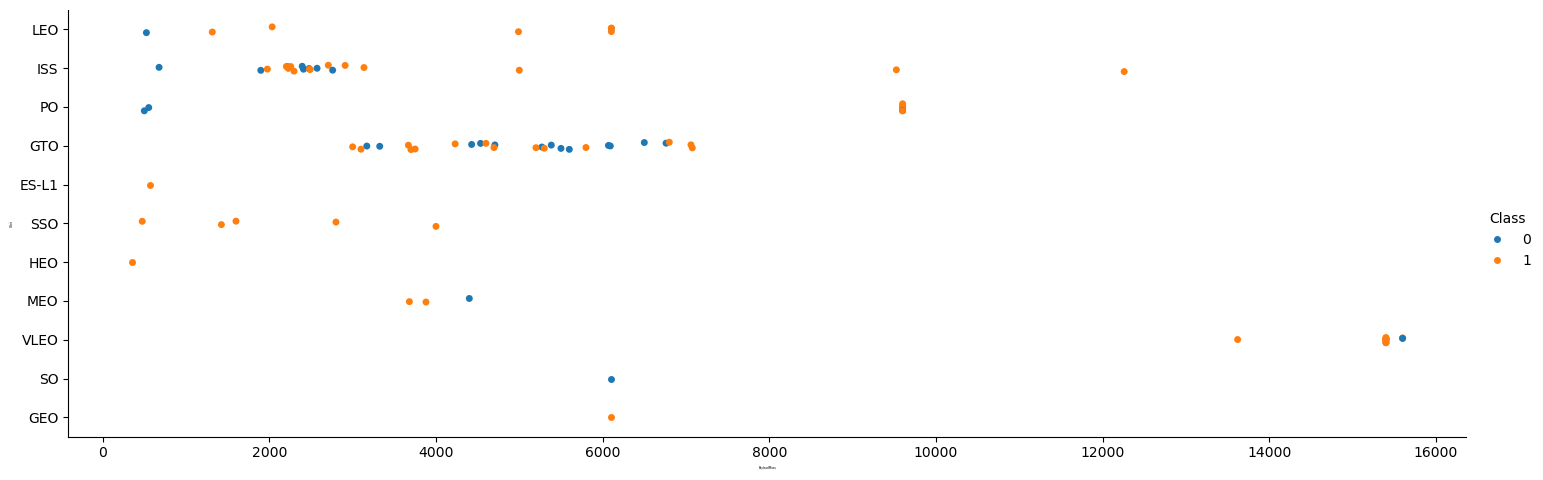

In [8]:
sns.catplot(y='Orbit', x='PayloadMass', hue="Class", data=df, aspect = 3)
plt.xlabel("PayloadMass", fontsize =2)
plt.ylabel("Orbit", fontsize =2)
plt.show()







































